## Exploratory Data Analysis (EDA) of Automobile Dataset

In [ ]:
# Import necessary libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

---
## Load Dataset

In [ ]:
# Load the automobile dataset from a text file
automobiles_df = pd.read_csv('automobile.txt')

# Display first few rows to understand the data structure
automobiles_df.head()

---
## Data Cleaning
#### Drop Irrelevant Columns

In [ ]:
# Columns 'normalized-losses', 'symboling', and 'engine-location' are not needed for our analysis
columns_to_drop = ['normalized-losses', 'symboling', 'engine-location']
automobiles_df.drop(columns=columns_to_drop, inplace=True)

print(f"Columns after dropping {columns_to_drop}:\n{automobiles_df.columns.tolist()}")


#### Remove Duplicate Rows

In [ ]:
# Check for duplicate rows and remove them
print("Duplicate rows before removal:", automobiles_df.duplicated().sum())
automobiles_df.drop_duplicates(inplace=True)
print("Duplicate rows after removal:", automobiles_df.duplicated().sum())

#### Remove Rows with Missing or Invalid Data

In [ ]:
# Rows containing '?' indicate missing or invalid values; remove such rows for clean numeric processing
print("Rows before removing missing values:", automobiles_df.shape[0])

# Filter out any rows where any cell contains '?'
automobiles_df = automobiles_df[~automobiles_df.apply(lambda row: row.astype(str).str.contains(r'\?', regex=True)).any(axis=1)]

# Reset index after removal
automobiles_df.reset_index(drop=True, inplace=True)

print("Rows after removing missing values:", automobiles_df.shape[0])



#### Display The Cleaned DataFrame

In [ ]:
print("Cleaned DataFrame:\n", automobiles_df.head())

---
## Data Type Conversion

Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [ ]:
# Convert all numeric columns (int or float) to int64 using NumPy
for col in automobiles_df.select_dtypes(include=['float64', 'int64']).columns:
    # Fill any remaining NaNs with 0 just in case
    automobiles_df[col] = automobiles_df[col].fillna(0)

    # Convert column to int64
    automobiles_df[col] = automobiles_df[col].astype(np.int64)

# Confirm the data types
print("\nData types after conversion to int64:")
print(automobiles_df.dtypes)

make                 object
fuel-type            object
aspiration           object
num-of-doors         object
body-style           object
drive-wheels         object
wheel-base            int64
length                int64
width                 int64
height                int64
curb-weight           int64
engine-type          object
num-of-cylinders     object
engine-size           int64
fuel-system          object
bore                 object
stroke               object
compression-ratio     int64
horsepower           object
peak-rpm             object
city-mpg              int64
highway-mpg           int64
price                object
dtype: object


---
## Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [21]:
# Create a dataframe with all the cars in the "hatchback' category
hatchback_cars = automobiles_df[automobiles_df['body-style'] == 'hatchback']
hatchback_cars.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,wheel-base,length,width,height,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
2,alfa-romero,gas,std,two,hatchback,rwd,94,171,65,52,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
17,chevrolet,gas,std,two,hatchback,fwd,88,141,60,53,...,61,2bbl,2.91,3.03,9,48,5100,47,53,5151
18,chevrolet,gas,std,two,hatchback,fwd,94,155,63,52,...,90,2bbl,3.03,3.11,9,70,5400,38,43,6295
20,dodge,gas,std,two,hatchback,fwd,93,157,63,50,...,90,2bbl,2.97,3.23,9,68,5500,37,41,5572
21,dodge,gas,std,two,hatchback,fwd,93,157,63,50,...,90,2bbl,2.97,3.23,9,68,5500,31,38,6377


---
## Analysis and Visualization
**Identify relationships between variables (features)**

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

###  Top 5 Most Expensive vs Cheapest Cars

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

Comparison of Most Expensive vs Cheapest Cars:

      Category       make body-style price  highway-mpg  city-mpg
Most Expensive volkswagen      sedan  9995           32        26
Most Expensive     toyota  hatchback  9989           30        24
Most Expensive     subaru      sedan  9960           32        26
Most Expensive mitsubishi  hatchback  9959           30        23
Most Expensive     nissan      sedan  9549           34        27
      Cheapest     subaru      wagon 10198           31        25
      Cheapest      mazda      sedan 10245           32        26
      Cheapest      honda      sedan 10295           33        27
      Cheapest     toyota      sedan 10698           33        30
      Cheapest      isuzu  hatchback 11048           29        24


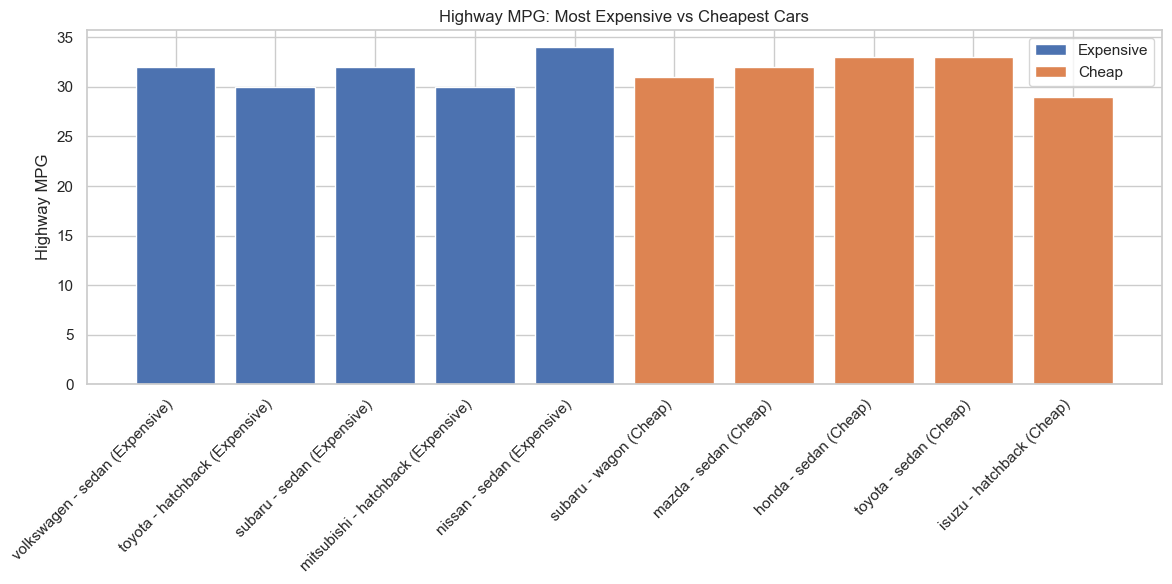

In [22]:
# Remove duplicate 'make' entries by keeping the first unique one after sorting
most_expensive = (
    automobiles_df.sort_values(by='price', ascending=False)
    .drop_duplicates(subset='make')
    .head(5)
)

cheapest = (
    automobiles_df.sort_values(by='price', ascending=True)
    .drop_duplicates(subset='make')
    .head(5)
)

# Combine both sets into one DataFrame with category labels
compare_df = pd.concat([
    most_expensive.assign(Category='Most Expensive'),
    cheapest.assign(Category='Cheapest')
])

# Select and rearrange relevant columns
comparison_table = compare_df[['Category', 'make', 'body-style', 'price', 'highway-mpg', 'city-mpg']]

# Display the comparison table
print("Comparison of Most Expensive vs Cheapest Cars:\n")
print(comparison_table.to_string(index=False))

# Add 'category' labels
most_expensive['category'] = 'Expensive'
cheapest['category'] = 'Cheap'

# Combine into one DataFrame
compare_df = pd.concat([most_expensive, cheapest])

# Plot highway-mpg comparison
plt.figure(figsize=(12, 6))
for cat in ['Expensive', 'Cheap']:
    subset = compare_df[compare_df['category'] == cat]
    labels = subset['make'] + ' - ' + subset['body-style'] + ' (' + cat + ')'
    plt.bar(labels, subset['highway-mpg'], label=cat)

plt.title('Highway MPG: Most Expensive vs Cheapest Cars')
plt.ylabel('Highway MPG')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()



**Observations:**

- Top 5 most expensive cars:
  - Volkswagen Sedan
  - Toyota Hatchback
  - Subaru Sedan
  - Mitsubishi Hatchback
  - Nissan Sedan

- Top 5 cheapest cars:
  - Subaru Wagon
  - Mazda Sedan
  - Honda Sedan
  - Toyota Sedan
  - Isuzu Harchback
     
- According to the table and bar graph, the highway-mpg and city-mpg of the most expensive cars and least expensive cars does not have a big diffrence.
- Thus, it can be conluded that moviecars are not worth the money spent on them based on their fuel economy. 

**Summary:**
- The fuel efficiency (highway MPG) between the most expensive and cheapest cars shows minimal difference, suggesting that higher price doesn’t necessarily guarantee better fuel economy.

### Most Fuel-Efficient Manufacturer

Compare the average mpg for each vehicle manufacture's vehicles.

Most fuel-efficient manufacturer: chevrolet (46.33 mpg)


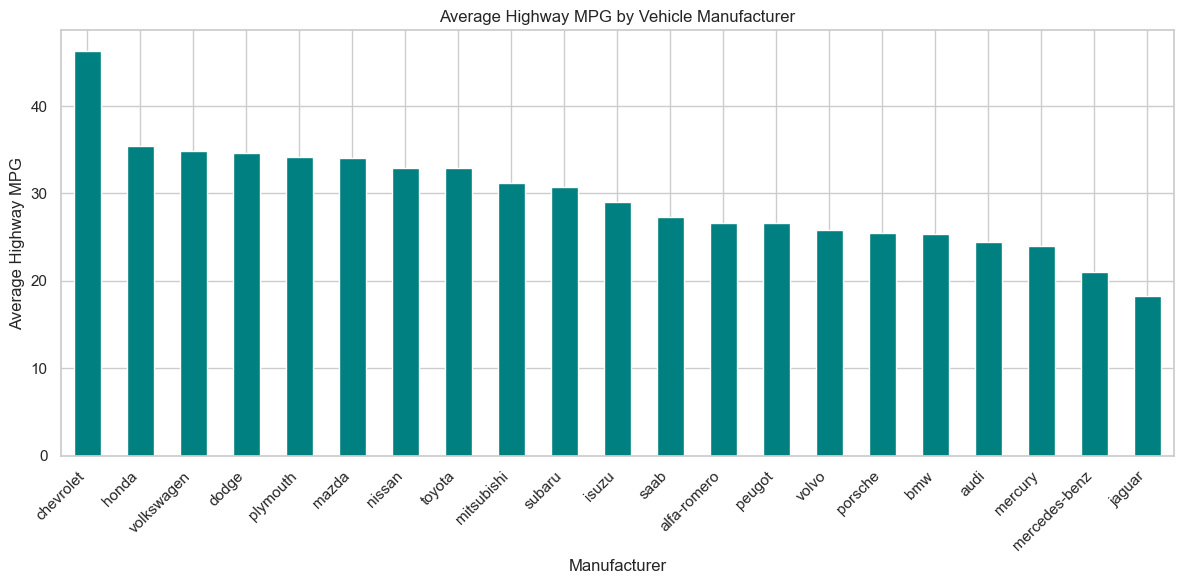

In [ ]:
# Calculate average highway MPG per manufacturer
avg_mpg_by_make = automobiles_df.groupby('make')['highway-mpg'].mean().sort_values(ascending=False)

# Display the manufacturer with the highest average mpg
most_efficient_make = avg_mpg_by_make.idxmax()
most_efficient_mpg = avg_mpg_by_make.max()

print(f"Most fuel-efficient manufacturer: {most_efficient_make} ({most_efficient_mpg:.2f} mpg)")

# Plot average highway MPG by manufacturer
plt.figure(figsize=(12, 6))
avg_mpg_by_make.plot(kind='bar', color='teal')
plt.title('Average Highway MPG by Vehicle Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Average Highway MPG')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




**Observation**

- According to the bar graph, Chevrolet leads as the manufacturer with the highest average fuel efficiency among its vehicles.

### Vehicles with Largest Engine Capacity


Top 5 vehicles with the largest engine capacity:
             make body-style  engine-size horsepower  price
45         jaguar      sedan          326        262  36000
64  mercedes-benz      sedan          308        184  40960
65  mercedes-benz    hardtop          304        184  45400
43         jaguar      sedan          258        176  32250
62  mercedes-benz      sedan          234        155  34184


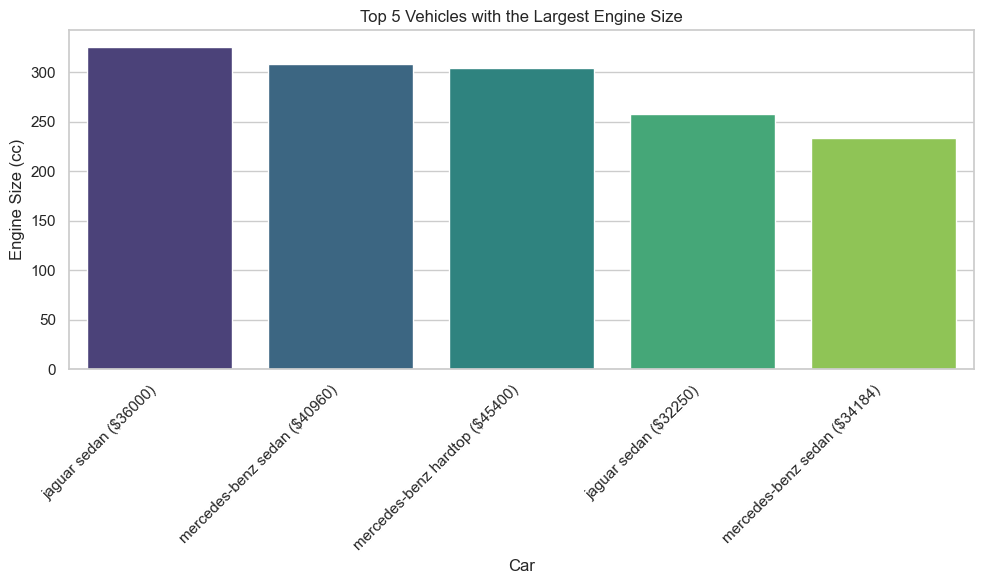

In [ ]:
# Remove duplicate entries by 'make' and 'engine-size' to get unique vehicles
unique_engines = automobiles_df.drop_duplicates(subset=['make', 'engine-size'])

# Sort descending by engine size and select top 5
largest_engines = unique_engines.sort_values(by='engine-size', ascending=False).head(5)

# Display the top 5 vehicles
print("Top 5 vehicles with the largest engine capacity:")
print(largest_engines[['make', 'body-style', 'engine-size', 'horsepower', 'price']])

# Add a combined label for plotting
largest_engines['car_name'] = (
    largest_engines['make'].astype(str) + ' ' +
    largest_engines['body-style'].astype(str) + ' ($' +
    largest_engines['price'].astype(str) + ')'
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='car_name',
    y='engine-size',
    hue='car_name',  # Assign x variable to hue
    data=largest_engines,
    palette='viridis',
    legend=False     # Disable legend since each bar is already labeled
)
plt.title('Top 5 Vehicles with the Largest Engine Size')
plt.xlabel('Car')
plt.ylabel('Engine Size (cc)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observations:**

- The Jaguar Sedan ($36 000) has the largest engine capasity.
- The Mercedes-Benz Sedan ($40 960) and the Mercedes-Benz Hardtop ($45 400) follows after the Jaguar Sedan ($36 000).
- The Jaguar Sedan($32 250) and the Mercedes-Benz ($34 184) also have large engine capasities.

**Summary:**
- Jaguar and Mercedes-Benz vehicles dominate the top spots in engine size and price, reflecting their focus on luxury and performance.

### Manufacturer with Most Car Models

Manufacturer with the most car entries (assuming each is a unique model):
make
toyota    32
Name: count, dtype: int64

Top 5 manufacturers with most cars in dataset:
make
toyota        32
nissan        18
mitsubishi    13
honda         13
subaru        12
Name: count, dtype: int64


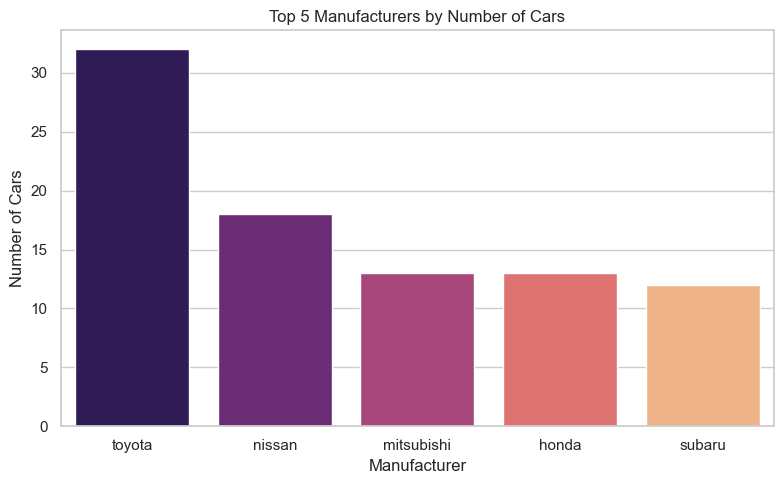

In [ ]:
# Count number of car entries per manufacturer
most_models = automobiles_df['make'].value_counts()

# Display the top manufacturer
print("Manufacturer with the most car entries (assuming each is a unique model):")
print(most_models.head(1))

print("\nTop 5 manufacturers with most cars in dataset:")
print(most_models.head(5))

# Prepare data for visualization
# Convert Series to DataFrame for plotting
top5_df = most_models.head(5).reset_index()
top5_df.columns = ['make', 'count']  # Rename columns properly

# Plot the top 5 manufacturers
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top5_df,
    x='make',
    y='count',
    hue='make',         # Assign hue
    palette='magma',
    legend=False        # Turn off legend since bars are already labeled
)

plt.title('Top 5 Manufacturers by Number of Cars')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show()



Observations

- Toyota has the most car entries, followed closely by Nissan and Mitsubishi..
- Honda and Subaru follows thereafter for the manufacturers with the most car entries